# Lab 3 - Prior and Posterior predictive distributions



import libraries

In [1]:
from cmdstanpy import CmdStanModel
import pandas as pd
import arviz as az 
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

### Modeling prior predictive distribution

Create a stan model

In [16]:
gen_quant = CmdStanModel(stan_file='M-03. Prior and Posterior predictive distributions/code_1.stan')


10:26:24 - cmdstanpy - INFO - compiling stan file /tmp/tmpen7hzqpi/tmpih4k276b.stan to exe file /workspace/M-03. Prior and Posterior predictive distributions/code_1
10:26:40 - cmdstanpy - INFO - compiled model executable: /workspace/M-03. Prior and Posterior predictive distributions/code_1


Sampling (pair of p and y)

In [17]:
samples = gen_quant.sample(fixed_param=True, 
                            iter_sampling=1000, 
                            iter_warmup=0,
                            adapt_engaged = False, 
                            chains = 1)

10:26:44 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

10:26:45 - cmdstanpy - INFO - CmdStan done processing.


convert to dataframe

In [20]:
df = samples.draws_pd()
df

,chain__,iter__,draw__,lp__,accept_stat__,N,p,y
0,1.0,1.0,1.0,0.0,0.0,50.0,0.131661,13.0
1,1.0,2.0,2.0,0.0,0.0,50.0,0.136061,9.0
2,1.0,3.0,3.0,0.0,0.0,50.0,0.187952,5.0
3,1.0,4.0,4.0,0.0,0.0,50.0,0.399132,20.0
4,1.0,5.0,5.0,0.0,0.0,50.0,0.144672,8.0
...,...,...,...,...,...,...,...,...
995,1.0,996.0,996.0,0.0,0.0,50.0,0.105137,5.0
996,1.0,997.0,997.0,0.0,0.0,50.0,0.127412,2.0
997,1.0,998.0,998.0,0.0,0.0,50.0,0.395591,22.0
998,1.0,999.0,999.0,0.0,0.0,50.0,0.285039,15.0


Compute ratio of allergic reactions with histogram

<Axes: >

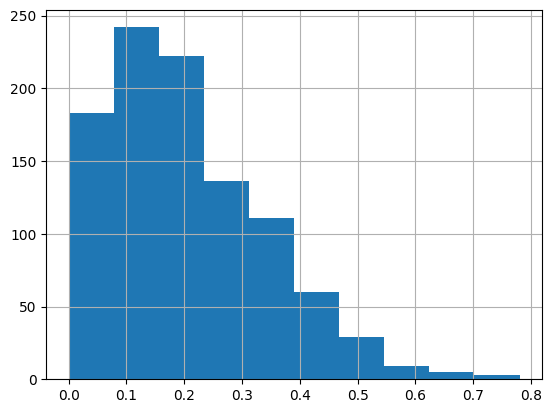

In [65]:
df['reaction_ratio'] = df['y'] / df['N']
df['reaction_ratio'].hist(bins=10)


verify mean of the ratio wheter is consistent with prior knowledge

In [27]:
df['reaction_ratio'].mean()

np.float64(0.20148000000000002)

*approximately 0.2 so prior is good*

### Modeling posterior and posterior predictive distribution

**1. Create a Stan model in which:**
* N and y are appropriately defined in the data block.
* p is defined in the parameters block.
* binomial likelihood and prior (selected using prior predictive distribution) are defined in the model block.
* new integer variable y_pred in the generated quantities block.
* sample y_pred using values of parameter p and input variable N

In [60]:
model_posterior = CmdStanModel(stan_file='M-03. Prior and Posterior predictive distributions/posterior_modeling.stan')

**2. Generate default number of samples from appropriate method in cmdstanpy.**

In [61]:
samples_post = model_posterior.sample(data = {'N': 50, 'y': 7},
                            fixed_param=True, 
                            iter_sampling=1000, 
                            iter_warmup=0,
                            adapt_engaged = False, 
                            chains = 1)

11:50:25 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

11:50:26 - cmdstanpy - INFO - CmdStan done processing.


to dataframe

In [62]:
df_post = samples_post.draws_pd()
df_post

,chain__,iter__,draw__,lp__,accept_stat__,p,y_pred
0,1.0,1.0,1.0,0.0,0.0,0.185842,9.0
1,1.0,2.0,2.0,0.0,0.0,0.185842,8.0
2,1.0,3.0,3.0,0.0,0.0,0.185842,9.0
3,1.0,4.0,4.0,0.0,0.0,0.185842,10.0
4,1.0,5.0,5.0,0.0,0.0,0.185842,7.0
...,...,...,...,...,...,...,...
995,1.0,996.0,996.0,0.0,0.0,0.185842,10.0
996,1.0,997.0,997.0,0.0,0.0,0.185842,13.0
997,1.0,998.0,998.0,0.0,0.0,0.185842,3.0
998,1.0,999.0,999.0,0.0,0.0,0.185842,8.0


**3. Compute ratio of predicted allergic reactions for each sample and create a histogram.**

np.float64(0.18804000000000004)

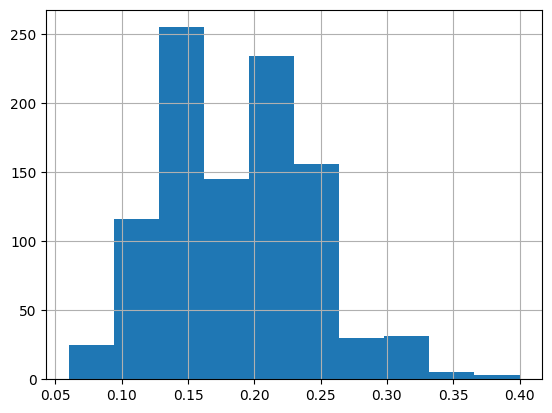

In [64]:
df_post['N'] = 50
df_post['reaction_ratio'] = df_post['y_pred'] / df_post['N']
df_post['reaction_ratio'].hist(bins=10)
df_post['reaction_ratio'].mean()


**4. Compute the expected value and 94% density interval of the predicted ratio, compare it with expected value and 94% density interval of parameter p. Use arviz package.**

In [67]:
# convert to numpy array FOR ALLOWING COMPUTATION IN ARVIZ
reaction_ratio_array = np.array(df_post['reaction_ratio'])
# Expected value and 94% density interval for predicted ratio
expected_ratio = reaction_ratio_array.mean()
density_interval_ratio = az.hdi(reaction_ratio_array, hdi_prob=0.94)

print("Expected value of the predicted ratio:", expected_ratio)
print(r"94% density interval for predicted ratio:", density_interval_ratio)


Expected value of the predicted ratio: 0.18804000000000004
94% density interval for predicted ratio: [0.1 0.3]


**5. Compute the probability that ratio is lower than the average probability from traditional vaccines (count the number of simulated ratios that are smaller).**

In [68]:
first_vaccines_prob = 0.2

# Count how many of the predicted ratios are smaller than the threshold
probability_lower_than_traditional = (df_post['reaction_ratio'] < first_vaccines_prob).mean()

# Print the result
print(f"The probability that the ratio is lower than the traditional vaccine probability (0.2): {probability_lower_than_traditional}")


The probability that the ratio is lower than the traditional vaccine probability (0.2): 0.541


### Conclusions

- **Comparison with Traditional Vaccine**:
  - The probability that the new vaccine is safer is approximately **54.1%** (more than half of the simulated values for `y_pred/N` were lower than 0.2).

- **Practical Implications**:
  - The results suggest that the new vaccine may be slightly safer, but the difference is not statistically significant (since the HDI includes both values lower and higher than 0.2). This requires further research with a larger sample size.

- **Summary**:
  - The Bayesian model confirmed the consistency of the data with the assumptions, but did not provide strong evidence of a significant improvement in safety. Additional verification, such as gathering more data, is necessary.
